In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Reproducing the findings of Hartlap+
Let's see the simulation-based inverse covariance underestimate the error size.
To do so, we first define the number of data dimension $p$ and the number of simulations $N$. Then we
1. create a random covariance = this is the true covariance, call it `c`
2. simulate $N$ samples, call `x`
3. estimate the covariance from the sims, call it `c_est`
4. Generate the test random samples that follow `c`
5. compute chi-square using `c` and `c_est`, and see the difference of chi-square distribution.

In [6]:
rng = np.random.default_rng(0)

In [7]:
def get_random_covariance(N):
    a = rng.random(N*N).reshape(N,N)
    c = np.dot(a, a.T)
    return c

In [8]:
p = 100
N = 300

# true
c = get_random_covariance(p)
ic= np.linalg.inv(c)

# generate samples
x = rng.multivariate_normal(np.zeros(p), c, N)
c_est = np.cov(x.T)
ic_est= np.linalg.inv(c_est)

# simulate validation samples
n_test = 10000
x2= rng.multivariate_normal(np.zeros(p), c, n_test)
# compute chi2
chi2    = np.array([np.dot(_, np.dot(ic, _)) for _ in x2])
chi2_est= np.array([np.dot(_, np.dot(ic_est, _)) for _ in x2])

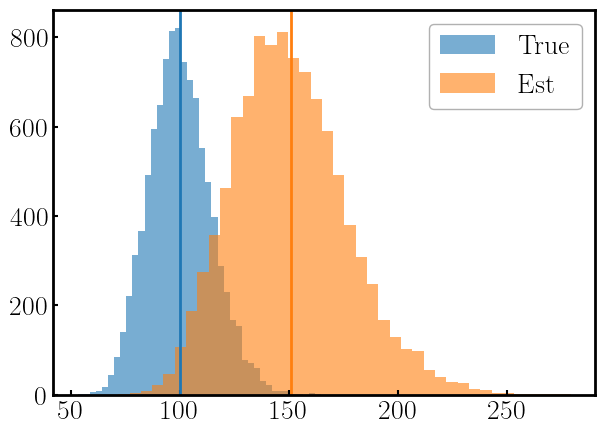

In [9]:
plt.figure()
# plt.hist(chi2, bins=bins, alpha=0.6, label='True')
# plt.hist(chi2_est, bins=bins, alpha=0.6, label='Est')
plt.hist(chi2, bins=40, alpha=0.6, label='True')
plt.hist(chi2_est, bins=40, alpha=0.6, label='Est')
# Hartlap prediction
plt.axvline(p, color='C0')
plt.axvline(p/((N-p-2)/(N-1)), color='C1')
plt.legend()
plt.show()

-----------------
## MOPED test

In [10]:
import emcee
import pymultinest
from getdist import plots, MCSamples

In [11]:
def model(params, base=None):
    if base is None:
        base = np.linspace(0, 5, p)
    # Example: 4 param model
    # out  = params[0]*np.exp(-params[1]*base) * (1+params[2]*np.exp(-(base-params[3])**2)/3)
    # Example: 3 param model
    out = params[0] * np.exp(-params[1]*base) + params[2]*np.exp(-(base-2.5)**2/2/0.3**2)
    return out

In [12]:
def compute_moped_matrix(ic, params, dp=0.01):
    # dim os params
    m = len(params)
    # fiducial model
    k = model(params)

    derivatives = np.zeros((m, p))
    for i in range(m):
        # plus
        pp = params.copy()
        pp[i] *= 1+dp
        k_plus = model(pp)
        # plus 2
        pp2 = params.copy()
        pp2[i] *= 1+2*dp
        k_plus2 = model(pp2)
        # minus
        pm = params.copy()
        pm[i] *= 1-dp
        k_minus = model(pm)
        # minus 2
        pm2 = params.copy()
        pm2[i] *= 1-2*dp
        k_minus2 = model(pm2)
        # derivative
        h = params[i] * dp
        d = (-k_plus2 + 8*k_plus - 8*k_minus + k_minus2) / 12/h
        # assign
        derivatives[i] = d

    # compute the moped matrix
    c = np.linalg.inv(ic)
    b = np.zeros((m,p))
    for i in range(m):
        mum_bq = np.einsum('i,qi->q', derivatives[i], b)
        bm = np.dot(ic, derivatives[i])
        bm-= np.einsum('q,qi->i', mum_bq, b)
        bm/= np.abs(np.einsum('i,ij,j->', bm, c, bm))**0.5
        # update matrix
        b[i,:] = bm

    return b

In [13]:
def lnpost(data, params, ic, b=None, boundary=None):
    theo = model(params)
    if b is not None:
        data = np.dot(b, data)
        theo = np.dot(b, theo)
        c = np.linalg.inv(ic)
        c = np.dot(b, np.dot(c, b.T))
        ic= np.linalg.inv(c)
    diff = data - theo
    chi2 = np.dot(diff, np.dot(ic, diff))
    out = -0.5*chi2

    if boundary is not None:
        for i in range(len(params)):
            if params[i] < boundary[i][0] or params[i] > boundary[i][1]:
                out = -np.inf
    return out

def sample_param(data, ic, params, b=None, nwalkers=10, boundary=None, f_hartlap=1):
    # def temporary_lnpost(params):
    #     return lnpost(data, params, ic, b, boundary) * f_hartlap
    # ndim = len(params)
    # pos = [params + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]
    # sampler = emcee.EnsembleSampler(nwalkers, ndim, temporary_lnpost)
    # sampler.run_mcmc(pos, 2000)
    # samples = sampler.get_chain(discard=100, thin=15, flat=True)
    # return samples

    def lnpost_temp(cube, ndim, nparams):
        params = cube
        return lnpost(data, params, ic, b) * f_hartlap

    def prior_temp(cube, ndim, nparams):
        for i in range(ndim):
            cube[i] = cube[i] * (boundary[i][1] - boundary[i][0]) + boundary[i][0]
    
    n_params = len(params)
    pymultinest.run(lnpost_temp, prior_temp, n_params, outputfiles_basename='../output/moped-toy/temp', resume=False, verbose=False, n_live_points=200)

    samples = np.loadtxt('../output/moped-toy/temp.txt')
    weight = samples[:,0]
    samples = samples[:,2:]

    print(f_hartlap)
    return samples, weight

#### Noiseless data case

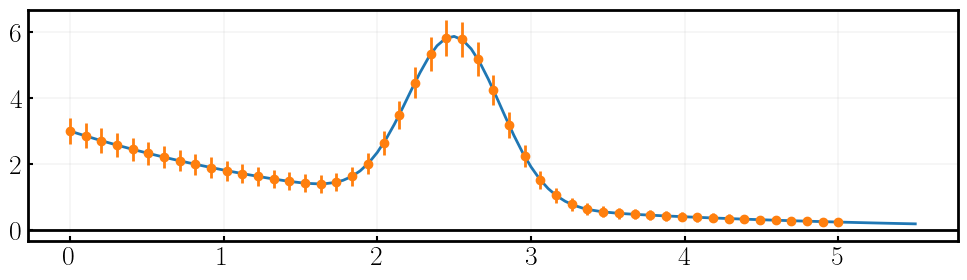

In [14]:
# problem setup
p = 50
N = 54

# data
params = [3, 0.5, 5]
data = model(params)

# true covariance
c = np.diag(data*0.05)
ic= np.linalg.inv(c)

# sim cov
x = rng.multivariate_normal(np.zeros(p), c, N)
c_est = np.cov(x.T)
ic_est= np.linalg.inv(c_est)

plt.figure(figsize=(12, 3))
# plt.yscale('log')
plt.axhline(0.0, color='k')
plt.grid()
_ = np.linspace(0, 5.5, 100)
plt.plot(_, model(params, _), label='Model')
plt.errorbar(np.linspace(0, 5, p), data, yerr=np.diag(c)**0.5, label='Data', fmt='.')
plt.show()

In [15]:
names = ['a', 'b', 'c']
boundary = [[0, 5], [0, 2], [0, 10]]

# 1. with true covariance
%time samples, w = sample_param(data, ic, params, boundary=boundary)
mcs = MCSamples(samples=samples, names=names, label='True', weights=w)
print('True', samples.shape)

# 2. with estimated covariance
%time samples_est, w = sample_param(data, ic_est, params, boundary=boundary, f_hartlap=(N-p-2)/(N-1))
mcs_est = MCSamples(samples=samples_est, names=names, label=f'Cov from {N} sims', weights=w)
print('Estimated', samples_est.shape)

# 3. moped compression
b = compute_moped_matrix(ic_est, params)
# %time samples_moped, w = sample_param(data, ic_est, params, b=b, boundary=boundary, f_hartlap=(N-len(params)-2)/(N-1))
# %time samples_moped, w = sample_param(data, ic_est, params, b=b, boundary=boundary, f_hartlap=(N-p-2)/(N-1))
%time samples_moped, w = sample_param(data, ic_est, params, b=b, boundary=boundary)
mcs_moped = MCSamples(samples=samples_moped, names=names, label=f'MOPED', weights=w)
print('MOPED', samples_moped.shape)

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3
 *****************************************************
 ln(ev)=  -9.3561353346283198      +/-  0.19719373056920064     
 Total Likelihood Evaluations:         3151
 Sampling finished. Exiting MultiNest
1
CPU times: user 663 ms, sys: 110 ms, total: 773 ms
Wall time: 830 ms
Removed no burn in
True (2063, 3)
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3
 *****************************************************
 ln(ev)=  -7.7582882060022378      +/-  0.17639683857792413     
 Total Likelihood Evaluations:         2755
 Sampling finished. Exiting MultiNest
0.03773584905660377
CPU times: user 611 ms, sys: 71.7 ms, total: 683 ms
Wall time: 748 ms
Removed no burn in
Estimated (1906, 3)
 ***

Text(0.5, 1.02, 'data dimension = 50')

<Figure size 600x600 with 0 Axes>

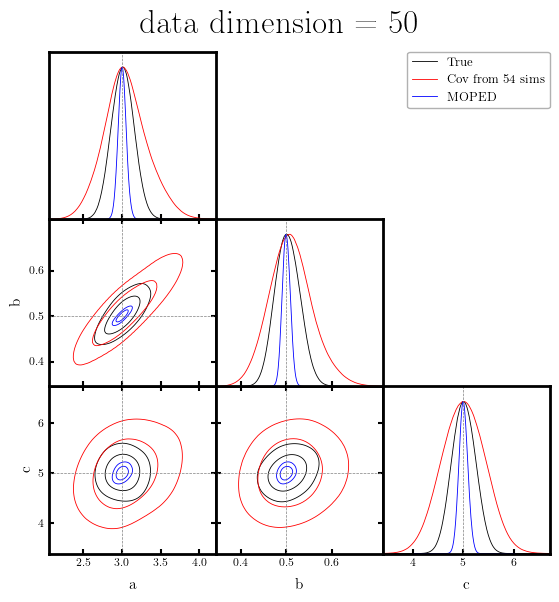

In [17]:
g = plots.get_single_plotter(ratio=1)
g.triangle_plot([mcs, mcs_est, mcs_moped], markers=params, fill=False)
plt.suptitle(f'data dimension = {p}', y=1.02)

## noisy case
Here we test the MOPED compression works even on noisy data.

We worry about the scenario where the simuation-based covariance mistakenly underestimate the variance of a specific data vector element due to small number of realization, and the MOPED mistakenly upweight the data vector element that has larger noise than estimated, then it would be possible that the compressed data vector is **not** robust against the noise realization.

*Possible counter argument*: as long as the compressed covariance is accurate, this mistake in choosing the noisy element of the uncompressed data vector could be taken into account by the compressed covariance.

In [18]:
%%time
# noise realizations by true covariance
ns = rng.multivariate_normal(np.zeros(p), c, 10)

mcs_n = []
mcs_moped_n = []
for i, n in enumerate(ns):
    data = model(params) + n
    # true
    samples, w = sample_param(data, ic, params, boundary=boundary)
    _ = MCSamples(samples=samples, names=names, label=f'True n{i}', weights=w)
    mcs_n.append(_)
    # moped
    samples, w = sample_param(data, ic, params, b=b, boundary=boundary, f_hartlap=(N-len(params)-2)/(N-1))
    _ = MCSamples(samples=samples, names=names, label=f'MOPED n{i}', weights=w)
    mcs_moped_n.append(_)

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3
 *****************************************************
 ln(ev)=  -31.600690486140508      +/-  0.19811604788321041     
 Total Likelihood Evaluations:         3347
 Sampling finished. Exiting MultiNest
1
Removed no burn in
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3
 *****************************************************
 ln(ev)=  -5.3234359256207169      +/-  0.14362763477422835     
 Total Likelihood Evaluations:         2312
 Sampling finished. Exiting MultiNest
0.9245283018867925
Removed no burn in
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3


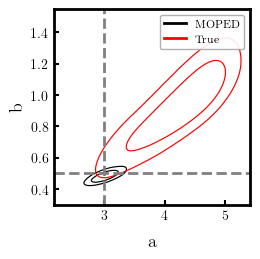

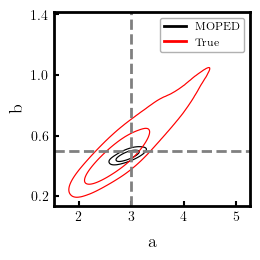

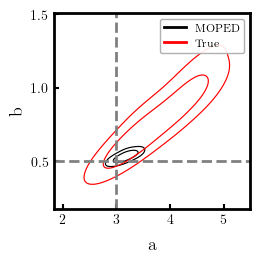

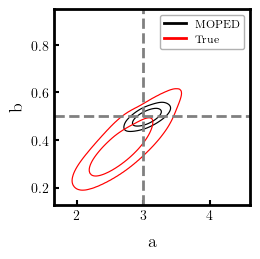

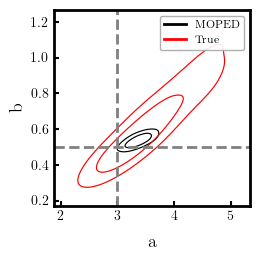

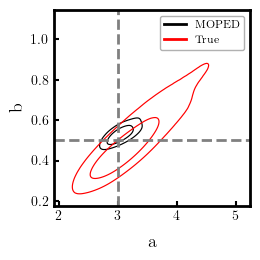

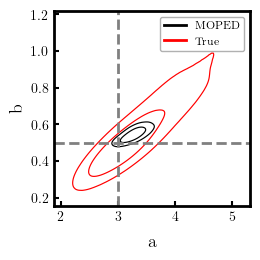

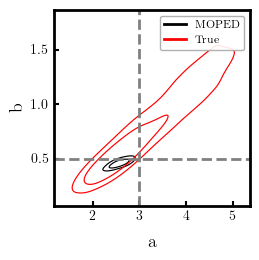

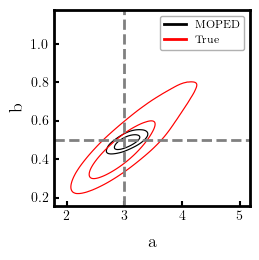

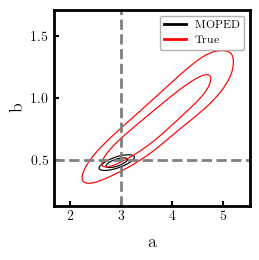

In [20]:
for i in range(len(mcs_moped_n)):
    g = plots.get_single_plotter(ratio=1, width_inch=3)
    g.plot_2d([mcs_n[i], mcs_moped_n[i]], 'a', 'b', filled=False, contour_colors=['k', 'red'])
    ax = g.subplots[0,0]
    ax.axhline(params[1], color='gray', ls='--')
    ax.axvline(params[0], color='gray', ls='--')
    ax.plot(np.nan, color='k', label='MOPED')
    ax.plot(np.nan, color='red', label='True')
    ax.legend(fontsize=8)
    plt.show()